# Proyek Akhir: Menyelesaikan Permasalahan Jaya Jaya Institut

- Nama: Krisna Santosa

- Email: mamang.krisna15@gmail.com

- Id Dicoding: krisna_santosa

## Persiapan
Pada tahap ini dilakukan import library, penetapan parameter eksperimen, dan sumber data agar analisis dapat direproduksi secara konsisten.

### Menyiapkan library yang dibutuhkan

In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

RANDOM_STATE = 42
PROJECT_DIR = Path.cwd()
DATA_URL = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv"

sns.set_theme(style="whitegrid")

### Menyiapkan data yang akan digunakan

## Data Understanding
Tahap ini memeriksa ukuran data, tipe data, kualitas data (missing dan duplikasi), serta distribusi target `Status` sebagai dasar analisis lanjutan.

Shape: (4424, 37)

Jumlah kolom: 37

5 data teratas:


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



Tipe data:


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
dtype,int64,int64,int64,int64,int64,int64,float64,int64,int64,int64,...,int64,int64,int64,int64,float64,int64,float64,float64,float64,object



Missing values (kolom dengan missing > 0):


,0



Jumlah data duplikat: 0

Distribusi target Status:


,count
Status,
Graduate,2209
Dropout,1421
Enrolled,794


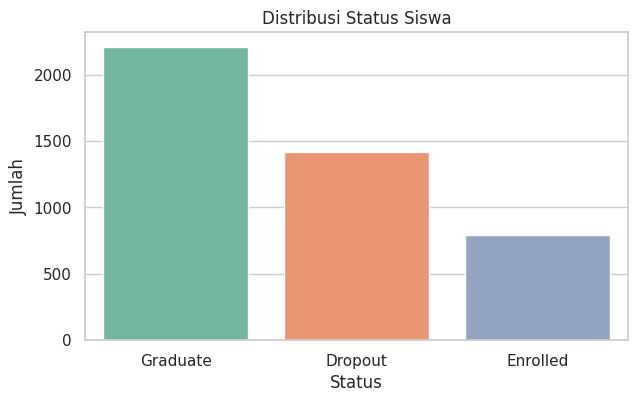

In [2]:
df = pd.read_csv(DATA_URL, sep=";")

print("Shape:", df.shape)
print("\nJumlah kolom:", len(df.columns))
print("\n5 data teratas:")
display(df.head())

print("\nTipe data:")
display(df.dtypes.to_frame("dtype").T)

missing_counts = df.isna().sum().sort_values(ascending=False)
print("\nMissing values (kolom dengan missing > 0):")
display(missing_counts[missing_counts > 0])

duplicate_count = int(df.duplicated().sum())
print(f"\nJumlah data duplikat: {duplicate_count}")

print("\nDistribusi target Status:")
display(df["Status"].value_counts(dropna=False).to_frame("count"))

plt.figure(figsize=(7, 4))
status_counts = df["Status"].value_counts()
sns.barplot(x=status_counts.index, y=status_counts.values, hue=status_counts.index, legend=False, palette="Set2")
plt.title("Distribusi Status Siswa")
plt.ylabel("Jumlah")
plt.xlabel("Status")
plt.show()

### Insight Data Understanding
1. Dataset berisi 4.424 baris dan 37 fitur, sehingga cukup representatif untuk membangun model klasifikasi.
2. Tidak ditemukan missing values maupun duplikasi pada data mentah yang dibaca pada eksperimen ini.
3. Distribusi target tidak seimbang ringan: `Graduate` paling banyak, `Dropout` urutan kedua, dan `Enrolled` paling sedikit.
4. Karena fokus bisnis adalah deteksi dini dropout, kelas target kemudian disederhanakan menjadi biner (`Dropout` vs `Non-Dropout`).

## Exploratory Data Analysis (EDA)

### EDA Univariate
Analisis univariate untuk memahami distribusi fitur numerik dan kategorikal utama sebelum pemodelan.

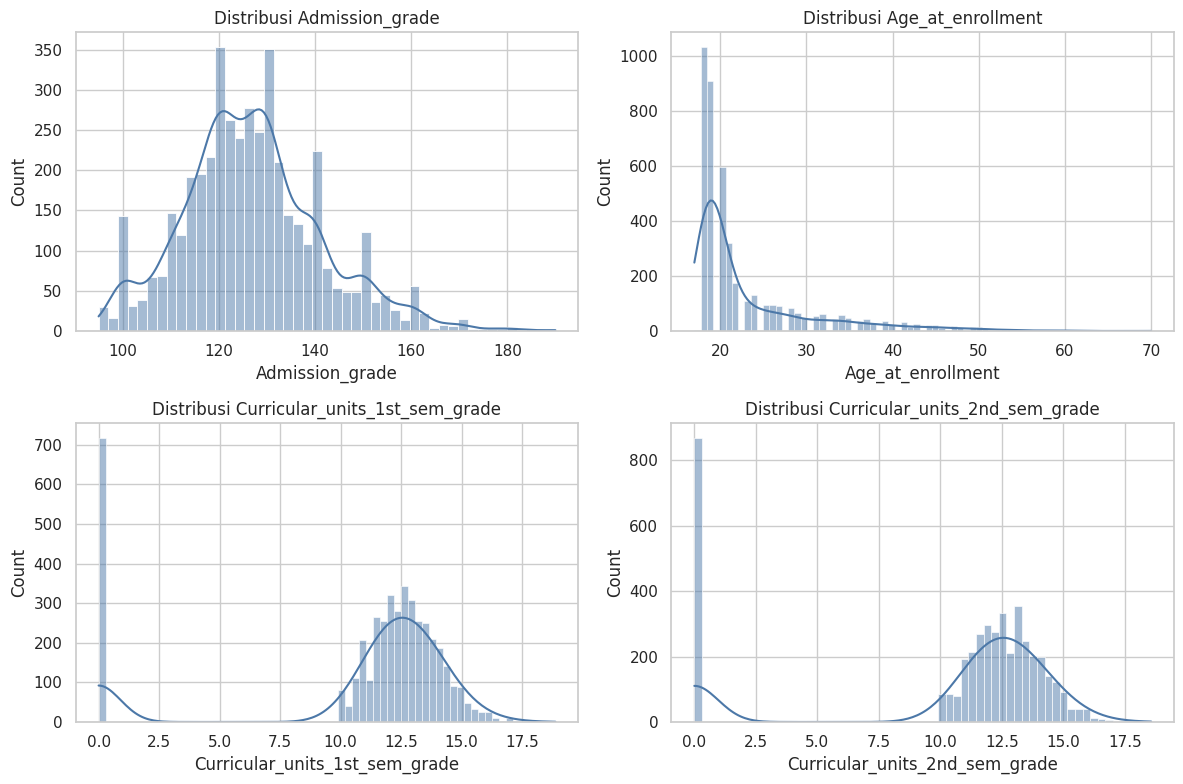

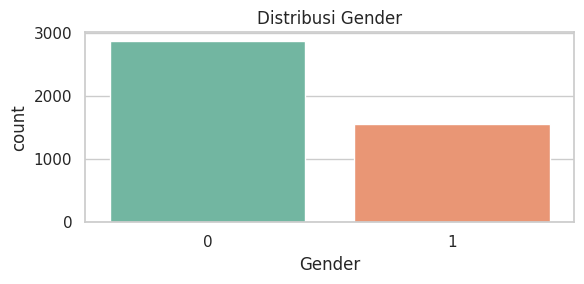

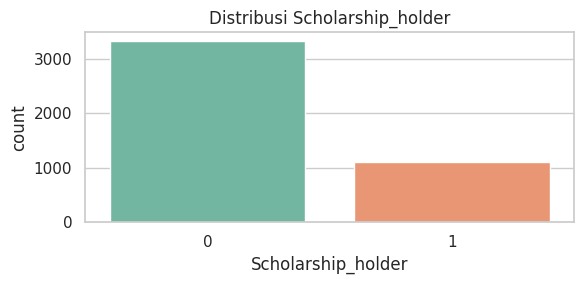

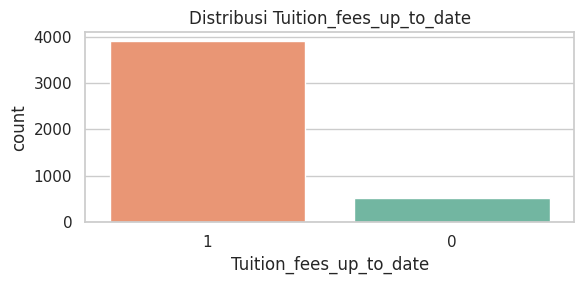

In [3]:
num_cols = [
    "Admission_grade",
    "Age_at_enrollment",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_grade",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C78A8")
    ax.set_title(f"Distribusi {col}")
plt.tight_layout()
plt.show()

cat_cols = ["Gender", "Scholarship_holder", "Tuition_fees_up_to_date"]
for col in cat_cols:
    plt.figure(figsize=(6, 3))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, hue=col, legend=False, palette="Set2")
    plt.title(f"Distribusi {col}")
    plt.tight_layout()
    plt.show()

### Insight EDA Univariate
1. `Admission_grade` berpusat pada rentang menengah (sekitar 120-135) dengan ekor ke kanan.
2. `Age_at_enrollment` sangat terkonsentrasi pada usia muda (sekitar akhir belasan hingga awal 20-an) dengan tail panjang ke usia lebih tinggi.
3. Distribusi nilai semester 1 dan 2 menunjukkan konsentrasi utama pada rentang 11-14, namun ada lonjakan pada nilai 0 yang perlu diwaspadai sebagai indikator performa akademik rendah/tidak tuntas.
4. Pada fitur kategorikal, mayoritas siswa berada pada kategori `Gender=0`, `Scholarship_holder=0`, dan `Tuition_fees_up_to_date=1`.

### EDA Bivariate
Analisis hubungan antara target dropout dengan variabel-variabel penting.

,Course,total_student,dropout_rate
0,33,12,0.666667
7,9130,141,0.553191
6,9119,170,0.541176
16,9991,268,0.507463
15,9853,192,0.442708
3,9003,210,0.409524
12,9556,86,0.383721
1,171,215,0.381395
10,9254,252,0.380952
13,9670,268,0.354478


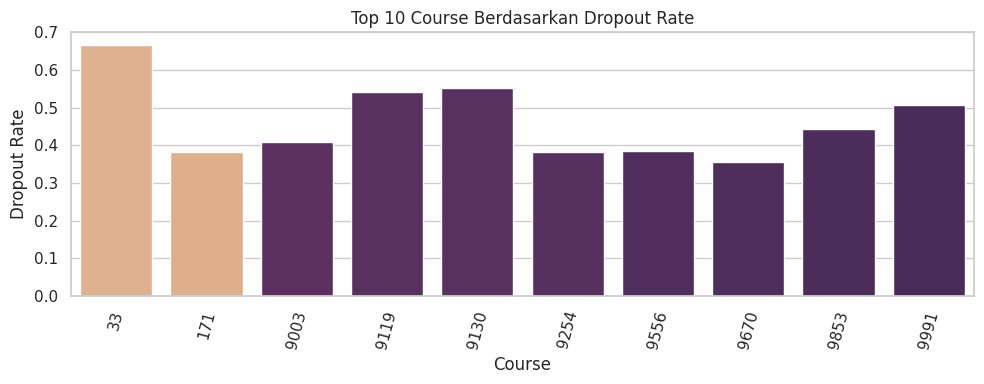

,Gender,total_student,dropout_rate
0,0,2868,0.251046
1,1,1556,0.450514


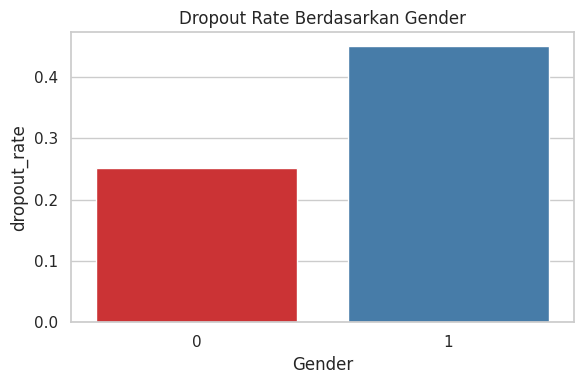

In [4]:
eda_df = df.copy()
eda_df["dropout_target"] = (eda_df["Status"] == "Dropout").astype(int)

course_risk = (
    eda_df.groupby("Course", as_index=False)
    .agg(total_student=("dropout_target", "size"), dropout_rate=("dropout_target", "mean"))
    .sort_values("dropout_rate", ascending=False)
)

display(course_risk.head(10))

plt.figure(figsize=(10, 4))
sns.barplot(
    data=course_risk.head(10),
    x="Course",
    y="dropout_rate",
    hue="Course",
    legend=False,
    palette="flare",
)
plt.title("Top 10 Course Berdasarkan Dropout Rate")
plt.xticks(rotation=75)
plt.ylabel("Dropout Rate")
plt.tight_layout()
plt.show()

gender_risk = (
    eda_df.groupby("Gender", as_index=False)
    .agg(total_student=("dropout_target", "size"), dropout_rate=("dropout_target", "mean"))
)

display(gender_risk)

plt.figure(figsize=(6, 4))
sns.barplot(data=gender_risk, x="Gender", y="dropout_rate", hue="Gender", legend=False, palette="Set1")
plt.title("Dropout Rate Berdasarkan Gender")
plt.tight_layout()
plt.show()

### Insight EDA Bivariate
1. Dropout rate berbeda cukup tajam antar `Course`; pada output saat ini terlihat beberapa program studi berada pada level risiko tinggi (bahkan di atas 0.5).
2. Program studi dengan kode `33 (Biofuel Production Technologies)` terlihat sebagai salah satu yang tertinggi pada grafik Top 10 dropout rate.
3. Berdasarkan grafik gender, kelompok `Gender=1 (male)` memiliki dropout rate lebih tinggi dibanding `Gender=0 (female)` pada data ini.
4. Temuan ini menandakan intervensi sebaiknya diprioritaskan per segmen, bukan kebijakan seragam untuk semua siswa.

### EDA Multivariate
Melihat korelasi antar fitur numerik serta pola gabungan fitur terhadap dropout.

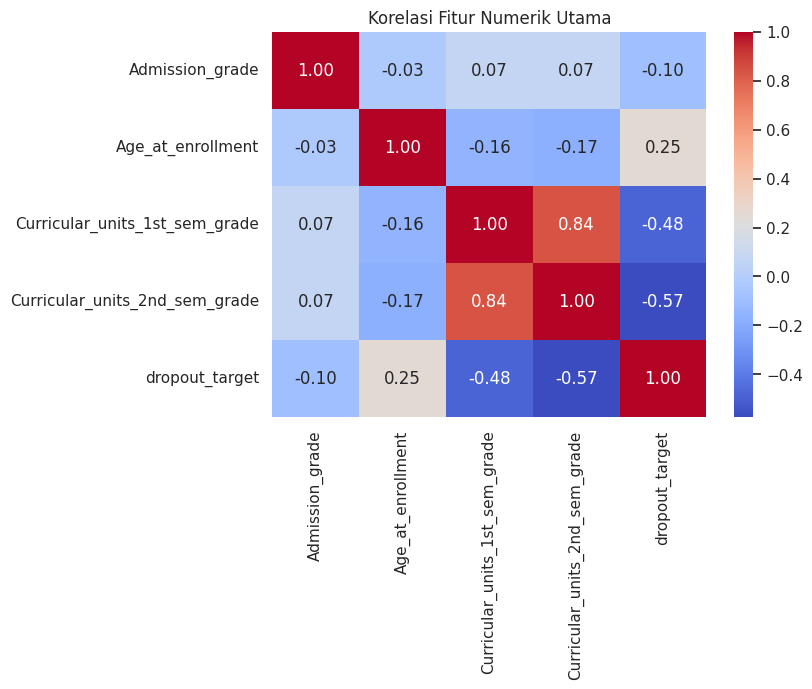

Gender,0,1
Tuition_fees_up_to_date,,
0,0.830258,0.902724
1,0.190605,0.361047


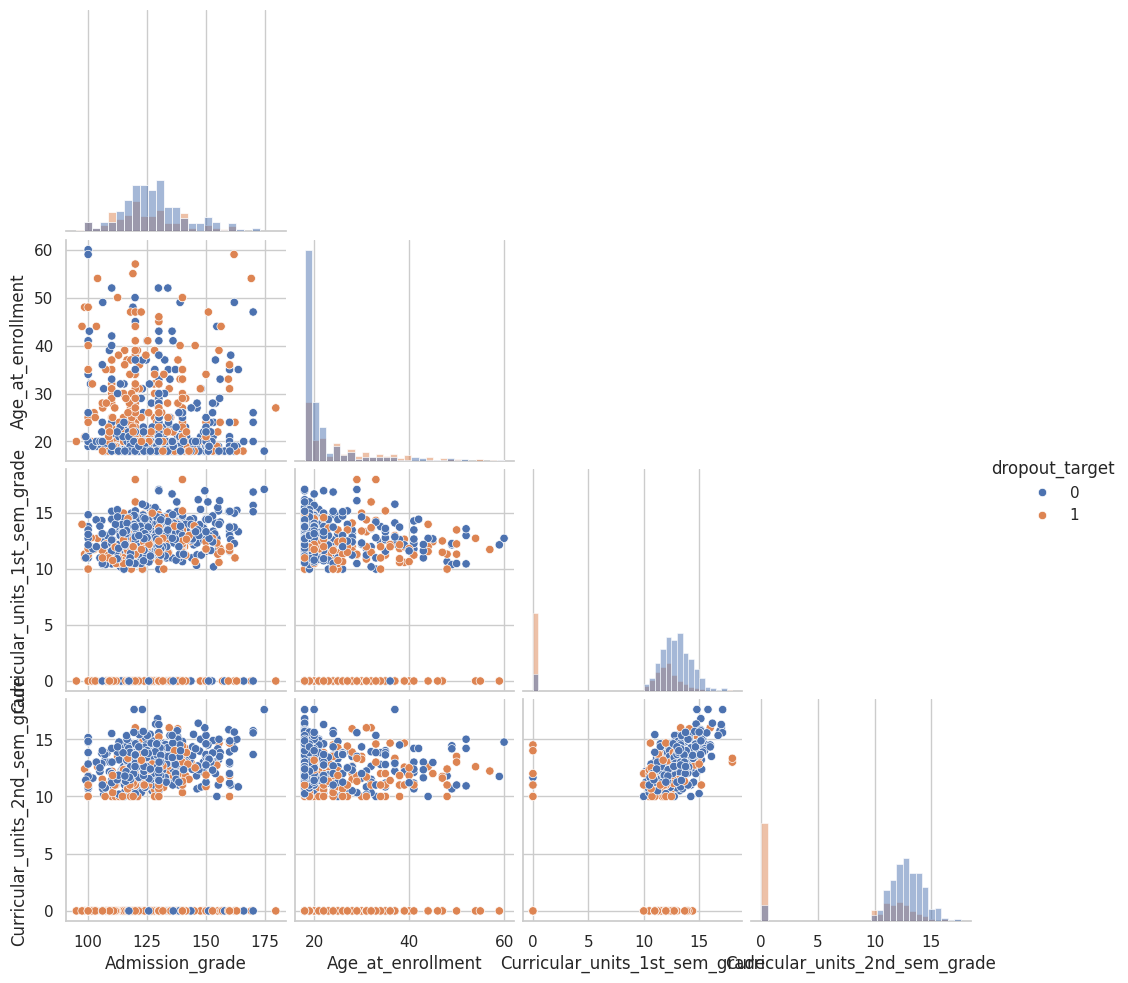

In [5]:
corr_cols = [
    "Admission_grade",
    "Age_at_enrollment",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_grade",
    "dropout_target",
]

corr_matrix = eda_df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Fitur Numerik Utama")
plt.show()

pivot_tuition_gender = pd.pivot_table(
    eda_df,
    index="Tuition_fees_up_to_date",
    columns="Gender",
    values="dropout_target",
    aggfunc="mean",
)
display(pivot_tuition_gender)

sample_pair = eda_df[[
    "Admission_grade",
    "Age_at_enrollment",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_grade",
    "dropout_target",
]].dropna().sample(800, random_state=RANDOM_STATE)

sns.pairplot(sample_pair, hue="dropout_target", corner=True, diag_kind="hist")
plt.show()

### Insight EDA Multivariate
1. Korelasi `Curricular_units_1st_sem_grade` dan `Curricular_units_2nd_sem_grade` sangat kuat positif (sekitar 0.84), menunjukkan konsistensi performa akademik lintas semester.
2. `dropout_target` berkorelasi negatif dengan nilai semester 1 dan 2 (sekitar -0.48 dan -0.57), artinya semakin baik nilai akademik, kecenderungan dropout menurun.
3. `Age_at_enrollment` berkorelasi positif moderat terhadap `dropout_target` (sekitar 0.25), mengindikasikan risiko dropout cenderung meningkat pada usia masuk yang lebih tinggi.
4. Pairplot memperlihatkan pemisahan kelas dropout lebih tampak pada area nilai akademik rendah, sehingga fitur akademik menjadi kandidat prediktor utama.

## Data Preparation / Preprocessing
Tahap ini menyiapkan data modeling, termasuk penanganan missing values secara eksplisit.

In [6]:
model_df = df.copy()

print("Missing values sebelum preprocessing:")
display(model_df.isna().sum()[model_df.isna().sum() > 0])

# Jika target kosong, data tersebut dibuang agar label training valid.
missing_target = int(model_df["Status"].isna().sum())
print(f"Jumlah missing pada target Status: {missing_target}")
model_df = model_df.dropna(subset=["Status"]).copy()

# Fokus klasifikasi biner: Dropout vs Non-Dropout.
model_df = model_df[model_df["Status"].isin(["Dropout", "Graduate", "Enrolled"])].copy()
model_df["dropout_target"] = (model_df["Status"] == "Dropout").astype(int)

x = model_df.drop(columns=["Status", "dropout_target"])
y = model_df["dropout_target"]

numeric_features = x.select_dtypes(include=["number"]).columns.tolist()
categorical_features = x.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)
print("Target distribution (train):")
print(y_train.value_counts(normalize=True))

Missing values sebelum preprocessing:


,0


Jumlah missing pada target Status: 0
Train shape: (3539, 36)
Test shape: (885, 36)
Target distribution (train):
dropout_target
0    0.678723
1    0.321277
Name: proportion, dtype: float64


### Insight Data Preparation / Preprocessing
1. Pada output eksperimen ini, missing value terdeteksi 0 termasuk pada target `Status`; namun langkah `dropna(subset=["Status"])` tetap dipertahankan sebagai kontrol kualitas jika data berubah di masa depan.
2. Fitur numerik diproses dengan imputasi median + standardisasi, sedangkan fitur kategorikal menggunakan imputasi modus + one-hot encoding.
3. Proporsi kelas pada data latih sekitar 67.9% Non-Dropout dan 32.1% Dropout, sehingga model tetap perlu memperhatikan ketidakseimbangan kelas moderat.

## Modeling
Model yang dibandingkan adalah Logistic Regression dan Random Forest dengan preprocessing yang sama agar perbandingan adil. Pemilihan model terbaik didasarkan pada ROC-AUC dan F1-score.

In [7]:
candidates = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
    ),
}

results = []
fitted_models = {}

for name, model in candidates.items():
    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ]
    )
    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)
    y_prob = pipeline.predict_proba(x_test)[:, 1]

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }
    results.append(metrics)
    fitted_models[name] = pipeline

result_df = pd.DataFrame(results).sort_values(["roc_auc", "f1_score"], ascending=False)
display(result_df)

best_model_name = result_df.iloc[0]["model"]
best_pipeline = fitted_models[best_model_name]
print("Model terbaik:", best_model_name)

,model,accuracy,precision,recall,f1_score,roc_auc
1,RandomForest,0.888136,0.868526,0.767606,0.814953,0.931464
0,LogisticRegression,0.873446,0.786667,0.830986,0.808219,0.927175


Model terbaik: RandomForest


### Insight Modeling
1. Perbandingan model dilakukan pada dua kandidat utama: Logistic Regression dan Random Forest dengan pipeline preprocessing yang identik.
2. Berdasarkan tabel metrik, Random Forest terpilih sebagai model terbaik pada data uji.
3. Pemilihan model mengutamakan kombinasi ROC-AUC dan F1-score agar tidak hanya akurat secara umum tetapi juga tetap baik dalam mendeteksi kelas Dropout.

## Evaluation
Tahap evaluasi menampilkan metrik klasifikasi utama, classification report, dan confusion matrix untuk menilai performa model pada data uji.

Accuracy : 0.8881
Precision: 0.8685
Recall   : 0.7676
F1-score : 0.815
ROC-AUC  : 0.9315

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.90      0.95      0.92       601
     Dropout       0.87      0.77      0.81       284

    accuracy                           0.89       885
   macro avg       0.88      0.86      0.87       885
weighted avg       0.89      0.89      0.89       885



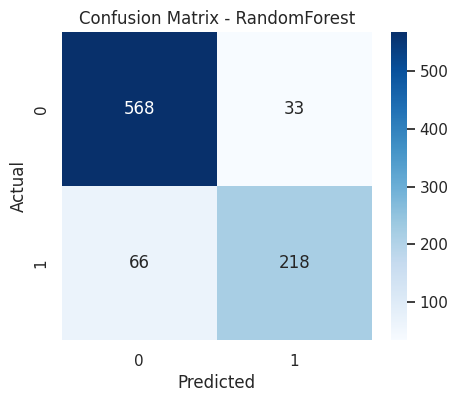

Notebook selesai sampai tahap evaluasi model.


In [8]:
y_pred_best = best_pipeline.predict(x_test)
y_prob_best = best_pipeline.predict_proba(x_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_best), 4))
print("Precision:", round(precision_score(y_test, y_pred_best), 4))
print("Recall   :", round(recall_score(y_test, y_pred_best), 4))
print("F1-score :", round(f1_score(y_test, y_pred_best), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_best), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=["Non-Dropout", "Dropout"]))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Notebook selesai sampai tahap evaluasi model.")

## Ringkasan Insight dan Karakteristik Siswa Dropout
1. Distribusi `Status` menunjukkan `Dropout` masih signifikan, sehingga diperlukan early warning yang konsisten dari sisi akademik dan finansial.
2. Faktor yang paling berkaitan dengan dropout adalah status pembayaran (`Tuition_fees_up_to_date`), status tunggakan (`Debtor`), performa akademik semester 1-2, serta program studi (`Course`).
3. Profil umum siswa dropout berdasarkan analisis data:
   - Nilai akademik awal lebih rendah: rata-rata `Curricular_units_1st_sem_grade = 7.26` dan `Curricular_units_2nd_sem_grade = 5.90` (non-dropout: 12.24 dan 12.28).
   - Median `Curricular_units_2nd_sem_grade` pada dropout adalah `0.0`, menandakan banyak siswa tidak mencapai performa minimum di semester 2.
   - Risiko finansial lebih tinggi: dropout rate pada `Tuition_fees_up_to_date = 0` sebesar `86.6%`, jauh lebih tinggi dibanding `24.7%` pada status up to date.
   - Usia saat masuk cenderung lebih tinggi: rata-rata `Age_at_enrollment` dropout `26.07` (median `23`) vs non-dropout `21.94` (median `19`).
   - Konsentrasi dropout lebih tinggi pada course tertentu (mis. `33`, `9130`, `9119`, `9991`).
4. Model terbaik (`Random Forest`) mencapai performa uji yang kuat: Accuracy 0.8881, Precision 0.8685, Recall 0.7676, F1-score 0.8150, ROC-AUC 0.9315.
5. Confusion matrix (TN=568, FP=33, FN=66, TP=218) menunjukkan model cukup baik menangkap siswa berisiko dan layak dipakai sebagai dasar intervensi terarah.